In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from funcs import lorenz
from esn import ESN

plt.rcParams['font.family'] = 'Times New Roman' #全体のフォントを設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 15

In [2]:
T = 10000
trans = 1000
free_run = 1000
dt = 0.02
sigma, beta, r = 10, 8/3, 28
dim = 3

args = (sigma, beta, r)
t = np.arange(0, (T+trans+free_run+1)*dt, dt)
rng = np.random.default_rng(seed=0)
X0 = rng.random(dim)

X = odeint(lorenz, X0, t, args=args)
X = X[trans:]

Text(0, 0.5, '$x$')

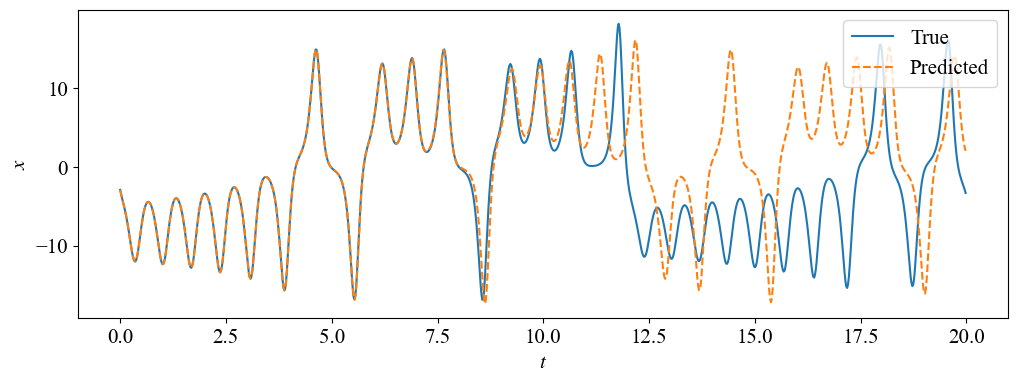

In [3]:
Nr = 300
input_scale = 0.1
average_degree = 6
rho = 0.6
beta = 10**-6
seed = 0

esn = ESN(dim, Nr, input_scale, average_degree, rho, seed)
esn.feed(X[:T, :])
esn.fit(X[1:T+1, :], beta=beta)

u = X[T, :]
V = np.zeros((dim, free_run))
for i in range(free_run):
    u = esn.predict(u)
    V[:, i] = u

plt.figure(figsize=(12, 4))
plt.plot(t[:free_run], X[T+1:T+1+free_run, 0], label='True')
plt.plot(t[:free_run], V[0, :], '--', label='Predicted')
plt.legend(loc='upper right')
plt.xlabel(r'$t$')
plt.ylabel(r'$x$')